# Using SymPy

In [77]:
import sympy
import math
import numpy as np
import matplotlib.pyplot as plt
sympy.init_printing()

In [78]:
def plot_f1_and_f2(f1, f2=None, x_min=-5, x_max=5, label1="f(x)", label2="f'(x)"):
    x = np.linspace(x_min, x_max,100)

    # Setting the axes at the centre.
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['left'].set_position('center')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    plt.plot(x, f1(x), 'r', label=label1)
    if not f2 is None:
        # If f2 is an array, it is passed as it is to be plotted as unlinked points.
        # If f2 is a function, f2(x) needs to be passed to plot it.        
        if isinstance(f2, np.ndarray):
            plt.plot(x, f2, 'bo', markersize=3, label=label2,)
        else:
            plt.plot(x, f2(x), 'b', label=label2)
    plt.legend()

    plt.show()

def plot_sympy_expr(expr, deriv_expr=None, symbol=None, x_min=-5, x_max=5, label1="f(x)", label2="f'(x)"):
    """Plot a SymPy expression and optionally its derivative using lambdify.
    
    Args:
        expr: SymPy symbolic expression to plot
        deriv_expr: Optional second expression to plot (e.g., derivative)
        symbol: SymPy symbol to use (default: x)
        x_min, x_max: Range for x-axis
        label1, label2: Labels for the functions
    """
    # Convert symbolic expressions to numerical functions using lambdify
    f1_raw = sympy.utilities.lambdify(symbol, expr, 'numpy')
    
    # Wrap to ensure constant expressions return arrays
    def f1(x_input):
        result = f1_raw(x_input)
        # If result is a scalar or 0-d array, broadcast to array of same shape as input
        if np.isscalar(result) or (isinstance(result, np.ndarray) and result.ndim == 0):
            return np.full_like(x_input, float(result))
        return result
    
    f2 = None
    if deriv_expr is not None:
        f2_raw = sympy.utilities.lambdify(symbol, deriv_expr, 'numpy')
        def f2(x_input):
            result = f2_raw(x_input)
            # If result is a scalar or 0-d array, broadcast to array of same shape as input
            if np.isscalar(result) or (isinstance(result, np.ndarray) and result.ndim == 0):
                return np.full_like(x_input, float(result))
            return result
    
    # Use the plotting function
    plot_f1_and_f2(f1, f2, x_min=x_min, x_max=x_max, label1=label1, label2=label2)

## Difference between math.sqrt and sympy.sqrt

**math.sqrt:**
- Returns a **floating-point approximation** of the square root
- Only works with numeric values (integers, floats)
- Fast computation but loses precision
- Example: `math.sqrt(2)` → `1.4142135623730951` (approximate decimal)

**sympy.sqrt:**
- Returns **symbolic/exact results** when possible
- Works with symbolic expressions, not just numbers
- Can simplify and manipulate expressions algebraically
- Example: `sympy.sqrt(2)` → `√2` (keeps the exact symbolic form)
- Can also return numeric approximations if requested
- Better for mathematical derivations and symbolic computation

**Key advantages of sympy.sqrt:**
- Preserves exact mathematical forms (e.g., `sqrt(8)` simplifies to `2*sqrt(2)`)
- Can work with variables and expressions
- Allows further symbolic manipulation
- Better for mathematical proofs and algebra

**When to use each:**
- Use `math.sqrt()` when you need quick numerical results
- Use `sympy.sqrt()` when working with symbolic math, exact results, or complex algebraic expressions

### Example: Computing sqrt(18)

Below we compare the output of `math.sqrt()` and `sympy.sqrt()` for the same input value (18). Notice how `math.sqrt()` returns a decimal approximation, while `sympy.sqrt()` simplifies the expression to its exact form (`3√2`).

In [79]:
print(math.sqrt(18))
sympy.sqrt(18)

4.242640687119285


### Converting to Numerical Approximation with sympy.N()

We can also convert SymPy's symbolic result into a numerical approximation with a specified number of significant figures:
- `sympy.N(expression, n)` → evaluates the expression numerically with `n` significant figures
- Example: `sympy.N(sympy.sqrt(18), 8)` → converts `3√2` to a decimal with 8 significant figures (result: `4.242641`)

In [80]:
sympy.N(sympy.sqrt(18), 8)

### Working with Symbolic Variables and Expressions

Below we create symbolic variables `x` and `y` using `sympy.symbols()`, and then define a symbolic expression. SymPy allows us to work with algebraic expressions that contain variables, rather than just numerical values. This is powerful for mathematical manipulation and simplification.

In [81]:
x, y = sympy.symbols('x y')
# Definition of the expression.
expr = 2 * x**2 - x * y
expr

### Creating More Complex Expressions

We can build more sophisticated symbolic expressions by combining variables, existing expressions, and powers. Below, we create a new expression by multiplying `x` with a combination of our previous expression and additional terms.

In [82]:
new_expr = x * (expr + x * y + x**3)
new_expr

### Expanding Expressions with sympy.expand()

The `sympy.expand()` function multiplies out all the terms in an expression by distributing operations and removing parentheses. This converts a factored form into its fully expanded polynomial form, making all terms explicit.

In [83]:
sympy.expand(new_expr)

### Factoring Expressions with sympy.factor()

The `sympy.factor()` function is the inverse of `expand()`. It takes an expanded polynomial expression and factors it back into its component form. This is useful for simplifying complex expressions and finding their underlying structure.

In [84]:
sympy.factor(new_expr)

### Evaluating Expressions with Specific Values

There are two ways to evaluate a symbolic expression with specific values:

**subs()** - Symbolic substitution
- Substitutes values and returns an **exact symbolic result**
- Returns integers, rationals, or simplified symbolic forms
- Use this when you need precise, exact answers

**evalf()** - Numerical evaluation  
- Converts the result to **floating-point** with specified precision
- May introduce small rounding errors (e.g., `5e-125` for zero)
- Use this when you need decimal approximations

For the expression `2x² - xy` at `x=1, y=2`:
- `subs()` gives exactly `0` (correct)
- `evalf()` gives `5.0e-125` (floating-point artifact)

In [85]:
print("Original expression:")
display(expr)
print("Expanded form:")
display(sympy.expand(expr))
print("Evaluated at x=1, y=2 (using subs):")
display(expr.subs({x:1, y:2}))
print("Evaluated at x=1, y=2 (using evalf):")
display(expr.evalf(subs={x:1, y:2}))

Original expression:


Expanded form:


Evaluated at x=1, y=2 (using subs):


Evaluated at x=1, y=2 (using evalf):


### Converting Symbolic Expressions to Functions with lambdify()

`sympy.utilities.lambdify()` converts a symbolic expression into a fast numerical function. The third argument specifies the backend:

- **`'numpy'`** → Vectorized operations on arrays (fastest, one-liner evaluation)
- **`'math'`** → Standard Python math module (works on single values, needs iteration)

Below we demonstrate the same symbolic expression `x²` evaluated on an array `[1,2,3,4]` using all three approaches:
1. Direct symbolic substitution with `subs()`
2. Lambdify with NumPy backend (vectorized)
3. Lambdify with math backend using list comprehension and for loop

In [86]:
input = np.array([1,2,3,4])
print(input)
# using x as a symbol previously defined
x_square = x ** 2
print("x² evaluated at different values:")
display(x_square.subs({x:1}))
display(x_square.subs({x:2}))
display(x_square.subs({x:3}))
display(x_square.subs({x:4}))

print()
print("Using lambdify with 'numpy' (vectorized):")
x_square_numpy = sympy.utilities.lambdify(x, x_square, 'numpy')
print(x_square_numpy(input))

print()
print("Using lambdify with 'math' (list comprehension):")
x_square_math = sympy.utilities.lambdify(x, x_square, 'math')
print([x_square_math(val) for val in input])

print()
print("Using lambdify with 'math' (for loop):")
x_square_math = sympy.utilities.lambdify(x, x_square, 'math')
results = []
for val in input:
    results.append(x_square_math(val))
print(results)

[1 2 3 4]
x² evaluated at different values:



Using lambdify with 'numpy' (vectorized):
[ 1  4  9 16]

Using lambdify with 'math' (list comprehension):
[np.int64(1), np.int64(4), np.int64(9), np.int64(16)]

Using lambdify with 'math' (for loop):
[np.int64(1), np.int64(4), np.int64(9), np.int64(16)]


### Computing Derivatives with sympy.diff()

`sympy.diff()` computes the derivative of a symbolic expression. Below we demonstrate:
- Creating a symbolic expression `x³`
- Computing its derivative using `sympy.diff()`
- Converting both to lambdified functions
- Plotting the original function and its derivative together

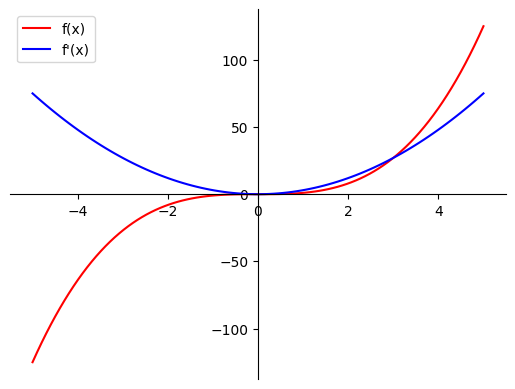

In [87]:
expr = x**3
display(expr)
dfdx_expr = sympy.diff(expr)
display(dfdx_expr)

expr_lambda = sympy.utilities.lambdify(x, expr, 'numpy')
diff_lambda = sympy.utilities.lambdify(x, dfdx_expr, 'numpy')

plot_f1_and_f2(expr_lambda, diff_lambda)

### Differentiation of a Constant

The derivative of any constant is **zero**. This is one of the fundamental rules of calculus:

- If $f(x) = c$ (where $c$ is a constant), then $f'(x) = 0$
- The constant function doesn't change as $x$ changes, so its rate of change is zero

Below we demonstrate this by computing the derivative of various constants using `sympy.diff()`

Derivatives of constants:

d/dx(5) = 

d/dx(-3) = 

d/dx(0) = 

d/dx(pi) = 

d/dx(E) = 

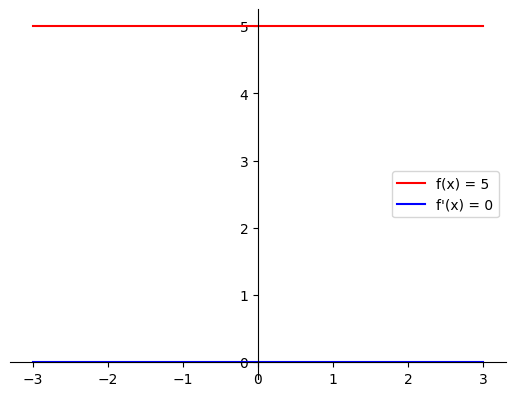

In [88]:
# Differentiate various constants
constant_value = 5
const_expr = sympy.sympify(constant_value)
derivative = sympy.diff(const_expr, x)

print("Derivatives of constants:")
print()

constants = [5, -3, 0, sympy.pi, sympy.E]

for c in constants:
    const_expr = sympy.sympify(c)
    derivative = sympy.diff(const_expr, x)
    print(f"d/dx({const_expr}) = ", end="")
    display(derivative)

print()

# Recompute const_expr and derivative for plotting (loop modified them to the last constant)
const_expr = sympy.sympify(constant_value)
derivative = sympy.diff(const_expr, x)

# Plot constant function and its derivative using plot_sympy_expr
plot_sympy_expr(const_expr, derivative, symbol=x, x_min=-3, x_max=3, label1=f"f(x) = {constant_value}", label2="f'(x) = 0")

### Differentiation of Exponential Function (e^x)

The exponential function $e^x$ has a special property: **its derivative is itself**.

$$\frac{d}{dx}(e^x) = e^x$$

This is one of the most important properties in calculus:
- The rate of change of $e^x$ at any point is equal to the value of $e^x$ at that point
- This self-replicating property is why exponential functions are so important in modeling growth and decay
- The slope of $e^x$ increases exponentially as $x$ increases

**Why is this important?**
- Exponential growth/decay processes (population, radioactive decay, compound interest)
- Solution to differential equations: $y' = y$ has the solution $y = Ce^x$
- Appears in calculus, differential equations, and physics throughout mathematics and science

Below we compute the derivative of $e^x$ using `sympy.diff()` and visualize both the function and its derivative.

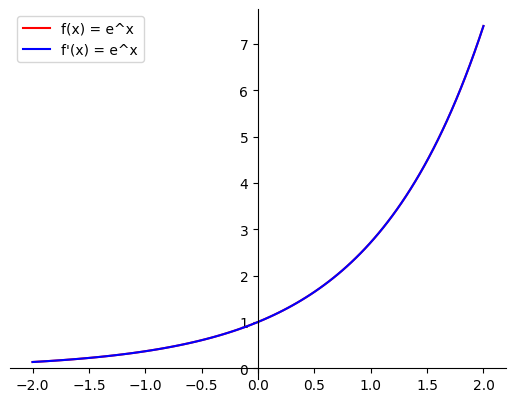

In [89]:
exp_expr = sympy.exp(x)
display(exp_expr)

dfdx_exp = sympy.diff(exp_expr, x)
display(dfdx_exp)

# Plot the exponential function and its derivative using plot_sympy_expr
plot_sympy_expr(exp_expr, dfdx_exp, symbol=x, x_min=-2, x_max=2, label1="f(x) = e^x", label2="f'(x) = e^x")

### Differentiation of Natural Logarithm: ln(x)

The natural logarithm function $\ln(x)$ (logarithm with base $e$) has a particularly simple derivative:

$$\frac{d}{dx}(\ln(x)) = \frac{1}{x}$$

**Key properties of this derivative:**
- The derivative is defined only for $x > 0$ (domain restriction)
- As $x \to 0^+$, the derivative $\frac{1}{x} \to \infty$ (slope becomes infinitely steep)
- As $x \to \infty$, the derivative $\frac{1}{x} \to 0$ (slope approaches zero)
- At $x = 1$, the derivative equals 1 (this is where $\ln(1) = 0$)

**Why is this important?**
- Logarithmic functions appear in many scientific and engineering applications
- The reciprocal relationship between $\ln(x)$ and $\frac{1}{x}$ reflects how the logarithm "slows down" growth
- Integration and differential equations often involve logarithmic functions

Below we compute the derivative of $\ln(x)$ using `sympy.diff()` and visualize both the function and its derivative. Note how the function grows slowly while its derivative decreases as $x$ increases.

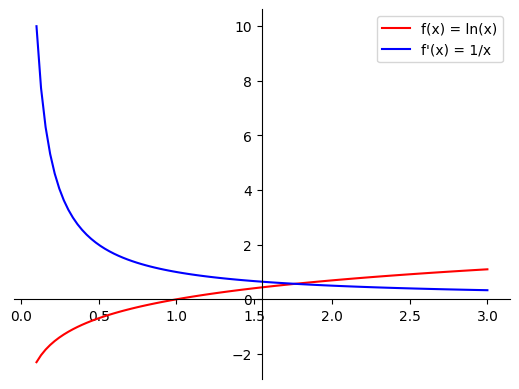

In [90]:
log_expr = sympy.log(x)
display(log_expr)

dfdx_log = sympy.diff(log_expr, x)
display(dfdx_log)

# Plot the natural logarithm function and its derivative using plot_sympy_expr
plot_sympy_expr(log_expr, dfdx_log, symbol=x, x_min=0.1, x_max=3, label1="f(x) = ln(x)", label2="f'(x) = 1/x")

### Differentiation of Trigonometric Functions: sin(x) and cos(x)

Trigonometric functions have simple and elegant derivatives that are related to each other:

$$\frac{d}{dx}(\sin(x)) = \cos(x)$$

$$\frac{d}{dx}(\cos(x)) = -\sin(x)$$

**Key observations:**
- The derivative of $\sin(x)$ is $\cos(x)$, which is the same function shifted by $\frac{\pi}{2}$ radians
- The derivative of $\cos(x)$ is $-\sin(x)$, which is $\sin(x)$ reflected (multiplied by -1)
- These are **reciprocal derivatives** - taking the derivative of $\sin(x)$ gives $\cos(x)$, and taking the derivative of $\cos(x)$ gives $-\sin(x)$
- This relationship continues indefinitely: the 2nd derivative of $\sin(x)$ is $-\sin(x)$, the 3rd is $-\cos(x)$, the 4th is $\sin(x)$ again

**Why are these relationships important?**
- Modeling oscillatory behavior (waves, vibrations, alternating electrical currents)
- Simple harmonic motion in physics
- Signal processing and Fourier analysis
- Understanding phase relationships between functions

Below we compute the derivatives and visualize the original functions with their derivatives.

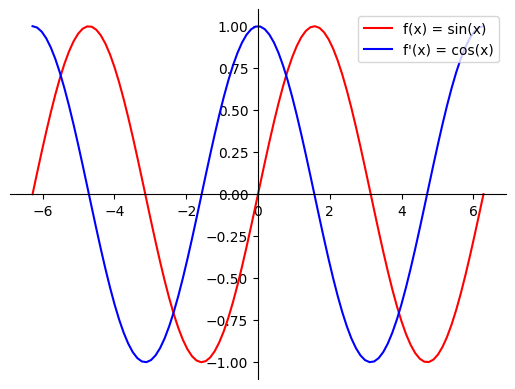

In [93]:
sin_expr = sympy.sin(x)
display(sin_expr)

dfdx_sin = sympy.diff(sin_expr, x)
display(dfdx_sin)

# Plot sin(x) and its derivative cos(x)
plot_sympy_expr(sin_expr, dfdx_sin, symbol=x, x_min=-2*float(sympy.pi), x_max=2*float(sympy.pi), label1="f(x) = sin(x)", label2="f'(x) = cos(x)")

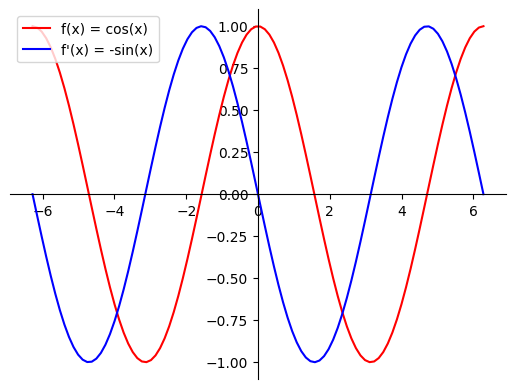

In [94]:
cos_expr = sympy.cos(x)
display(cos_expr)

dfdx_cos = sympy.diff(cos_expr, x)
display(dfdx_cos)

# Plot cos(x) and its derivative -sin(x)
plot_sympy_expr(cos_expr, dfdx_cos, symbol=x, x_min=-2*float(sympy.pi), x_max=2*float(sympy.pi), label1="f(x) = cos(x)", label2="f'(x) = -sin(x)")

## Differentiation Rules

### 1. Sum Rule

The derivative of a sum of functions equals the sum of their derivatives:

$$\frac{d}{dx}[f(x) + g(x)] = \frac{d}{dx}f(x) + \frac{d}{dx}g(x)$$

**Example:** $\frac{d}{dx}[x^2 + \sin(x)] = 2x + \cos(x)$

### 2. Product Rule

The derivative of a product of functions is given by:

$$\frac{d}{dx}[f(x) \cdot g(x)] = f'(x) \cdot g(x) + f(x) \cdot g'(x)$$

**Example:** $\frac{d}{dx}[x^2 \cdot \sin(x)] = 2x \cdot \sin(x) + x^2 \cdot \cos(x)$

### 3. Multiplication by Scalar (Constant Multiple Rule)

The derivative of a constant times a function equals the constant times the derivative of the function:

$$\frac{d}{dx}[c \cdot f(x)] = c \cdot \frac{d}{dx}f(x)$$

**Example:** $\frac{d}{dx}[5 \cdot x^3] = 5 \cdot 3x^2 = 15x^2$

These rules allow us to differentiate complex expressions by breaking them down into simpler components. Below we demonstrate each rule using SymPy.

In [95]:
print("=" * 60)
print("SUM RULE: d/dx[f(x) + g(x)] = f'(x) + g'(x)")
print("=" * 60)

# Define f(x) = x^2 and g(x) = sin(x)
f_sum = x**2
g_sum = sympy.sin(x)
combined_sum = f_sum + g_sum

print(f"\nf(x) = {f_sum}")
print(f"g(x) = {g_sum}")
print(f"\nf(x) + g(x) = {combined_sum}")

# Compute derivatives
df_sum = sympy.diff(f_sum, x)
dg_sum = sympy.diff(g_sum, x)
d_combined_sum = sympy.diff(combined_sum, x)

print(f"\nf'(x) = {df_sum}")
print(f"g'(x) = {dg_sum}")
print(f"\n[f(x) + g(x)]' = {d_combined_sum}")
print(f"f'(x) + g'(x) = {df_sum + dg_sum}")
print(f"\nVerification: d_combined_sum == df_sum + dg_sum: {sympy.simplify(d_combined_sum - (df_sum + dg_sum)) == 0}")

SUM RULE: d/dx[f(x) + g(x)] = f'(x) + g'(x)

f(x) = x**2
g(x) = sin(x)

f(x) + g(x) = x**2 + sin(x)

f'(x) = 2*x
g'(x) = cos(x)

[f(x) + g(x)]' = 2*x + cos(x)
f'(x) + g'(x) = 2*x + cos(x)

Verification: d_combined_sum == df_sum + dg_sum: True


In [96]:
print("\n" + "=" * 60)
print("PRODUCT RULE: d/dx[f(x) * g(x)] = f'(x)*g(x) + f(x)*g'(x)")
print("=" * 60)

# Define f(x) = x^2 and g(x) = sin(x)
f_prod = x**2
g_prod = sympy.sin(x)
combined_prod = f_prod * g_prod

print(f"\nf(x) = {f_prod}")
print(f"g(x) = {g_prod}")
print(f"\nf(x) * g(x) = {combined_prod}")

# Compute derivatives
df_prod = sympy.diff(f_prod, x)
dg_prod = sympy.diff(g_prod, x)
d_combined_prod = sympy.diff(combined_prod, x)

# Product rule formula: d[f*g]/dx = f'*g + f*g'
product_rule_result = df_prod * g_prod + f_prod * dg_prod

print(f"\nf'(x) = {df_prod}")
print(f"g'(x) = {dg_prod}")
print(f"\n[f(x) * g(x)]' = {d_combined_prod}")
print(f"f'(x)*g(x) + f(x)*g'(x) = {sympy.expand(product_rule_result)}")
print(f"\nVerification: d_combined_prod == f'*g + f*g': {sympy.simplify(d_combined_prod - product_rule_result) == 0}")


PRODUCT RULE: d/dx[f(x) * g(x)] = f'(x)*g(x) + f(x)*g'(x)

f(x) = x**2
g(x) = sin(x)

f(x) * g(x) = x**2*sin(x)

f'(x) = 2*x
g'(x) = cos(x)

[f(x) * g(x)]' = x**2*cos(x) + 2*x*sin(x)
f'(x)*g(x) + f(x)*g'(x) = x**2*cos(x) + 2*x*sin(x)

Verification: d_combined_prod == f'*g + f*g': True


In [97]:
print("\n" + "=" * 60)
print("CONSTANT MULTIPLE RULE: d/dx[c * f(x)] = c * f'(x)")
print("=" * 60)

# Define constant c and function f(x) = x^3
c = 5
f_scalar = x**3
combined_scalar = c * f_scalar

print(f"\nc = {c}")
print(f"f(x) = {f_scalar}")
print(f"\nc * f(x) = {combined_scalar}")

# Compute derivatives
df_scalar = sympy.diff(f_scalar, x)
d_combined_scalar = sympy.diff(combined_scalar, x)

# Constant multiple rule: d[c*f]/dx = c * df/dx
scalar_rule_result = c * df_scalar

print(f"\nf'(x) = {df_scalar}")
print(f"\n[c * f(x)]' = {d_combined_scalar}")
print(f"c * f'(x) = {scalar_rule_result}")
print(f"\nVerification: d_combined_scalar == c * f'(x): {sympy.simplify(d_combined_scalar - scalar_rule_result) == 0}")


CONSTANT MULTIPLE RULE: d/dx[c * f(x)] = c * f'(x)

c = 5
f(x) = x**3

c * f(x) = 5*x**3

f'(x) = 3*x**2

[c * f(x)]' = 15*x**2
c * f'(x) = 15*x**2

Verification: d_combined_scalar == c * f'(x): True


### 4. Chain Rule

The chain rule is used to find the derivative of **composite functions** (functions within functions):

$$\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$$

**Or in alternative notation:**
$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

where $y = f(u)$ and $u = g(x)$.

**Key concept:**
- Take the derivative of the "outer function" with respect to the inner function
- Multiply by the derivative of the "inner function"
- This is often called "differentiate the outside, keep the inside, then multiply by the derivative of the inside"

**Examples:**
- $f(x) = (x^2 + 1)^3$: outer function is $(\cdot)^3$, inner function is $x^2 + 1$
  - $f'(x) = 3(x^2 + 1)^2 \cdot 2x = 6x(x^2 + 1)^2$

- $f(x) = e^{2x}$: outer function is $e^{(\cdot)}$, inner function is $2x$
  - $f'(x) = e^{2x} \cdot 2 = 2e^{2x}$

- $f(x) = \sin(x^2)$: outer function is $\sin(\cdot)$, inner function is $x^2$
  - $f'(x) = \cos(x^2) \cdot 2x = 2x\cos(x^2)$

**Why is the chain rule important?**
- Most real-world functions are composite functions
- It's essential for differentiation of logarithms, exponentials, and trigonometric functions
- Fundamental for solving differential equations and optimization problems

Below we demonstrate the chain rule using SymPy's symbolic differentiation and verify our results manually.

In [98]:
print("\n" + "=" * 60)
print("CHAIN RULE: d/dx[f(g(x))] = f'(g(x)) * g'(x)")
print("=" * 60)

# Example 1: f(x) = (x^2 + 1)^3
# Outer function: f(u) = u^3
# Inner function: g(x) = x^2 + 1
# f'(u) = 3u^2, g'(x) = 2x
# f'(g(x)) * g'(x) = 3(x^2 + 1)^2 * 2x = 6x(x^2 + 1)^2

print("\n" + "-" * 60)
print("Example 1: f(x) = (x^2 + 1)^3")
print("-" * 60)

# Define the composite function
u = sympy.symbols('u')
g_inner = x**2 + 1  # inner function
f_outer = u**3       # outer function
f_composite = (x**2 + 1)**3  # composite function

print(f"\nComposite function: f(x) = {f_composite}")

# Method 1: Direct differentiation using sympy
d_composite_1 = sympy.diff(f_composite, x)
print(f"\nDirect derivative: d/dx[f(x)] = {d_composite_1}")

# Method 2: Apply chain rule manually
# f'(u) = 3u^2, evaluated at u = g(x) = x^2 + 1
df_du = sympy.diff(f_outer, u)  # f'(u) = 3u^2
dg_dx = sympy.diff(g_inner, x)  # g'(x) = 2x
chain_rule_result = df_du.subs(u, g_inner) * dg_dx

print(f"\nUsing chain rule:")
print(f"  f'(u) = {df_du}")
print(f"  g'(x) = {dg_dx}")
print(f"  f'(g(x)) = {df_du.subs(u, g_inner)}")
print(f"  f'(g(x)) * g'(x) = {chain_rule_result}")
print(f"  Simplified: {sympy.expand(chain_rule_result)}")

print(f"\nVerification: d/dx[f(x)] == f'(g(x)) * g'(x): {sympy.simplify(d_composite_1 - chain_rule_result) == 0}")

# Example 2: f(x) = sin(x^2)
print("\n" + "-" * 60)
print("Example 2: f(x) = sin(x^2)")
print("-" * 60)

# Outer function: sin(u)
# Inner function: g(x) = x^2
# f'(u) = cos(u), g'(x) = 2x
# f'(g(x)) * g'(x) = cos(x^2) * 2x = 2x*cos(x^2)

g_inner_2 = x**2
f_composite_2 = sympy.sin(x**2)

print(f"\nComposite function: f(x) = {f_composite_2}")

# Method 1: Direct differentiation
d_composite_2 = sympy.diff(f_composite_2, x)
print(f"\nDirect derivative: d/dx[f(x)] = {d_composite_2}")

# Method 2: Chain rule
df_du_2 = sympy.diff(sympy.sin(u), u)  # cos(u)
dg_dx_2 = sympy.diff(g_inner_2, x)     # 2x
chain_rule_result_2 = df_du_2.subs(u, g_inner_2) * dg_dx_2

print(f"\nUsing chain rule:")
print(f"  f'(u) = {df_du_2}")
print(f"  g'(x) = {dg_dx_2}")
print(f"  f'(g(x)) = {df_du_2.subs(u, g_inner_2)}")
print(f"  f'(g(x)) * g'(x) = {chain_rule_result_2}")

print(f"\nVerification: d/dx[f(x)] == f'(g(x)) * g'(x): {sympy.simplify(d_composite_2 - chain_rule_result_2) == 0}")


CHAIN RULE: d/dx[f(g(x))] = f'(g(x)) * g'(x)

------------------------------------------------------------
Example 1: f(x) = (x^2 + 1)^3
------------------------------------------------------------

Composite function: f(x) = (x**2 + 1)**3

Direct derivative: d/dx[f(x)] = 6*x*(x**2 + 1)**2

Using chain rule:
  f'(u) = 3*u**2
  g'(x) = 2*x
  f'(g(x)) = 3*(x**2 + 1)**2
  f'(g(x)) * g'(x) = 6*x*(x**2 + 1)**2
  Simplified: 6*x**5 + 12*x**3 + 6*x

Verification: d/dx[f(x)] == f'(g(x)) * g'(x): True

------------------------------------------------------------
Example 2: f(x) = sin(x^2)
------------------------------------------------------------

Composite function: f(x) = sin(x**2)

Direct derivative: d/dx[f(x)] = 2*x*cos(x**2)

Using chain rule:
  f'(u) = cos(u)
  g'(x) = 2*x
  f'(g(x)) = cos(x**2)
  f'(g(x)) * g'(x) = 2*x*cos(x**2)

Verification: d/dx[f(x)] == f'(g(x)) * g'(x): True
